# 📊 Credit Risk Analysis — Koperasi Simpan Pinjam

**Tujuan:** Menganalisis data anggota peminjam untuk (1) memprediksi risiko gagal bayar (*supervised*) dan (2) mengelompokkan profil peminjam (*unsupervised*).

**Author:** Azera
**Domain:** Credit Risk / Koperasi Simpan Pinjam

---

## 1. Setup & Load Data

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.read_csv ("credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 2. Kenalan dengan Data (Data Understanding)

Sebelum modeling, kita pahami dulu: ukuran data, tipe kolom, dan missing values.

In [18]:
df.info()
df.describe()
# cek berapa yang gagal bayar vs lancar (target kita)
print(df['loan_status'].value_counts())
print(df['loan_status'].value_counts(normalize=True)) 

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           32581 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               32581 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.5 MB
loan_status
0    25473
1     7108
Name: count,

### 🔎 Temuan Awal

- **Ukuran:** 32.581 baris, 12 kolom — cukup besar untuk ML.
- **Missing values:** ada di 2 kolom (`person_emp_length` & `loan_int_rate`).
- **Imbalanced data:** hanya **22%** yang gagal bayar (status=1), sisanya 78% lancar.

> ⚠️ **Catatan penting:** Karena data *imbalanced*, akurasi saja bisa menyesatkan. Model yang menebak "semua lancar" otomatis dapat 78% akurasi, tapi gagal mendeteksi peminjam berisiko. Maka kita akan memperhatikan **recall & precision**, bukan hanya akurasi.

## 3. Data Cleaning

Mengisi *missing values* pada 2 kolom menggunakan **median** (lebih tahan terhadap outlier dibanding mean).

In [24]:
# cek detail missing values (berapa banyak yang kosong per kolom)
print(df.isnull().sum())

df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

# cek lagi — harusnya udah 0 semua
print(df.isnull().sum())

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


## 4. Exploratory Data Analysis (EDA)

Mencari pola: **siapa yang cenderung gagal bayar?** Insight di sini menjadi dasar interpretasi bisnis.

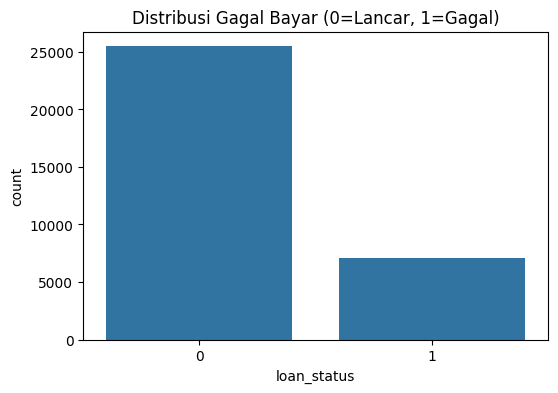

In [20]:
plt.figure(figsize=(6, 4))
sns.countplot(x='loan_status', data=df)
plt.title('Distribusi Gagal Bayar (0=Lancar, 1=Gagal)')
plt.show()

Peminjam yang gagal bayar cenderung punya bunga pinjaman LEBIH TINGGI (median ~13%) dibanding yang lancar (~11%).

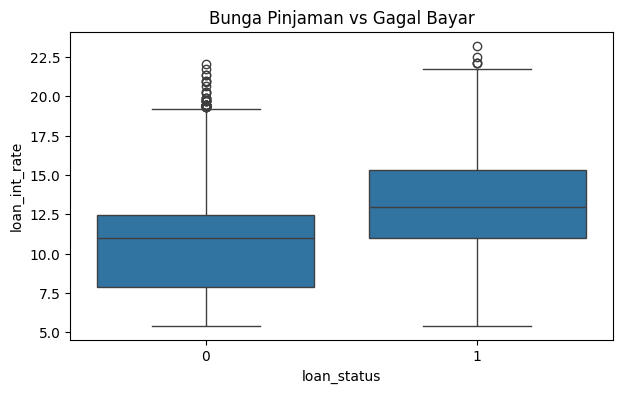

In [21]:
plt.figure(figsize=(7, 4))
sns.boxplot(x='loan_status', y='loan_int_rate', data=df)
plt.title('Bunga Pinjaman vs Gagal Bayar')
plt.show()

Peminjam yang gagal bayar punya rasio pinjaman/income LEBIH TINGGI dibanding yang lancar.

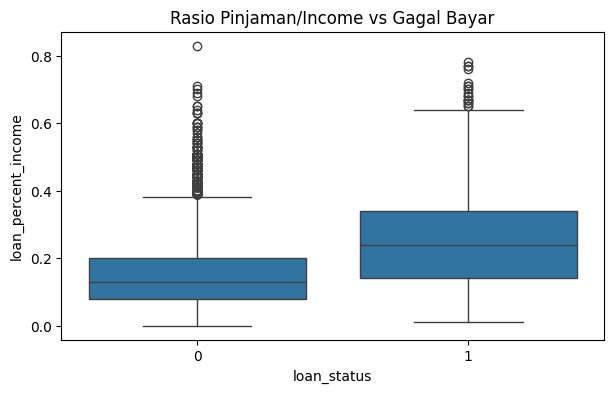

In [22]:
plt.figure(figsize=(7, 4))
sns.boxplot(x='loan_status', y='loan_percent_income', data=df)
plt.title('Rasio Pinjaman/Income vs Gagal Bayar')
plt.show()

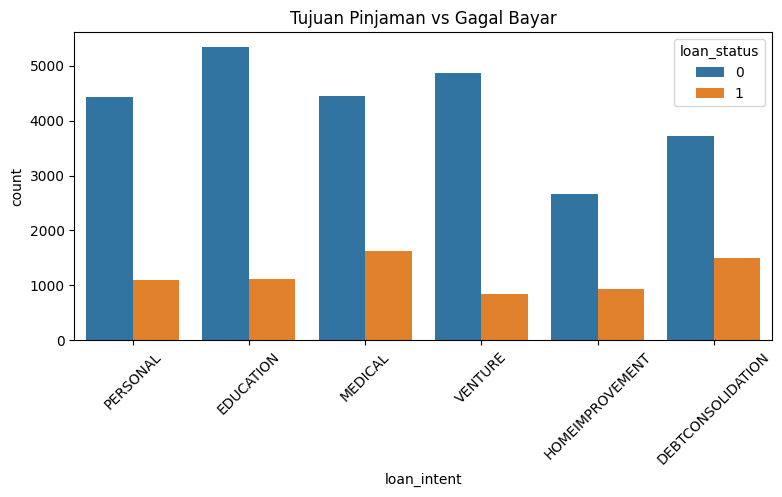

In [23]:
plt.figure(figsize=(9, 4))
sns.countplot(x='loan_intent', hue='loan_status', data=df)
plt.title('Tujuan Pinjaman vs Gagal Bayar')
plt.xticks(rotation=45)
plt.show()

## 5. Unsupervised Learning — Segmentasi Peminjam

Mengelompokkan peminjam berdasarkan profil (income, umur, jumlah pinjaman, dll) menggunakan K-Means, tanpa menggunakan label `loan_status`.

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# pilih fitur NUMERIK buat clustering (yang masuk akal buat segmentasi)
fitur_cluster = ['person_age', 'person_income', 'loan_amnt', 
                 'loan_int_rate', 'loan_percent_income']
X_cluster = df[fitur_cluster]

# scaling WAJIB (K-Means ngitung jarak, skala income vs umur timpang banget)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print("Bentuk data:", X_scaled.shape)

Bentuk data: (32581, 5)


### 6. Menentukan Jumlah Cluster (Elbow Method)

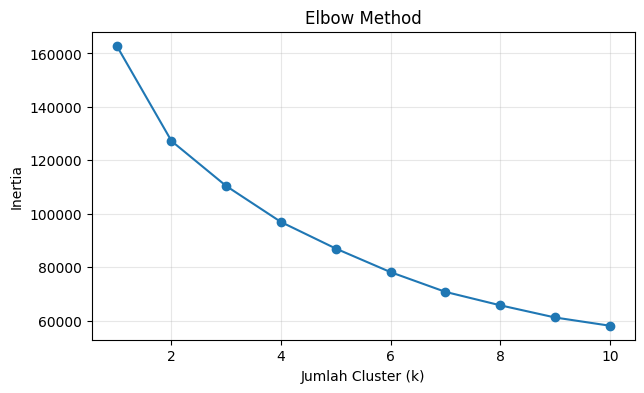

In [26]:
# coba k=1 sampai 10, ukur inertia
inertia = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# plot elbow
plt.figure(figsize=(7, 4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(alpha=0.3)
plt.show()

In [27]:
# cek juga silhouette score buat beberapa k
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k} -> silhouette: {score:.3f}")

k=2 -> silhouette: 0.271
k=3 -> silhouette: 0.264
k=4 -> silhouette: 0.217
k=5 -> silhouette: 0.229
k=6 -> silhouette: 0.229


### 7. K-Means Clustering (k=3)

Membagi peminjam menjadi 3 segmen. Dipilih k=3 karena lebih *actionable* untuk strategi koperasi (silhouette k=2 dan k=3 hampir sama).

In [28]:
# jalanin K-Means dengan k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)   # tambah kolom 'cluster' ke df

# lihat berapa anggota tiap cluster
print(df['cluster'].value_counts())

cluster
2    18273
1     9424
0     4884
Name: count, dtype: int64


In [29]:
# rata-rata tiap fitur per cluster (buat ngasih "nama" tiap kelompok)
profil = df.groupby('cluster')[fitur_cluster].mean()
print(profil)

         person_age  person_income     loan_amnt  loan_int_rate  \
cluster                                                           
0         38.805487   91511.301597   9040.985872      10.953491   
1         26.503926   64868.123833  16310.101868      12.131423   
2         25.410277   59898.552071   6269.836644      10.446071   

         loan_percent_income  
cluster                       
0                   0.132948  
1                   0.288247  
2                   0.119282  


In [31]:
# BONUS: cek rata-rata gagal bayar tiap cluster
# (ini ngehubungin unsupervised ke target — apakah cluster nyambung sama risiko?)
print(df.groupby('cluster')['loan_status'].mean())

cluster
0    0.155201
1    0.389856
2    0.146446
Name: loan_status, dtype: float64


### 🔎 Insight Segmentasi

K-Means membagi peminjam menjadi 3 segmen:

- **Cluster 0 — "Mapan & Aman"**: usia matang, income tinggi, rasio pinjaman rendah → gagal bayar 15.5%
- **Cluster 1 — "Berisiko Tinggi"**: pinjaman besar, rasio pinjaman/income tinggi (0.29) → **gagal bayar 39%** (3x lipat segmen lain)
- **Cluster 2 — "Muda & Hati-hati"**: income kecil tapi pinjaman konservatif → gagal bayar 14.6%

> **Temuan kunci:** Clustering (tanpa label) berhasil mengisolasi segmen berisiko tinggi murni dari profil finansial. Rasio pinjaman/income terbukti menjadi pembeda risiko utama.

### 9. Deteksi Anomali dengan DBSCAN

Mendeteksi peminjam dengan profil "tidak biasa" (outlier) yang berpotensi memerlukan perhatian khusus — menggunakan DBSCAN yang otomatis menandai noise sebagai -1.

In [32]:
from sklearn.cluster import DBSCAN

# DBSCAN pakai data yang udah di-scale (sama kayak K-Means)
dbscan = DBSCAN(eps=1.5, min_samples=10)
df['dbscan_label'] = dbscan.fit_predict(X_scaled)

# lihat hasil: berapa cluster & berapa outlier (-1)
print(df['dbscan_label'].value_counts())

dbscan_label
 0    32477
-1      104
Name: count, dtype: int64


In [33]:
# bandingin rata-rata profil: normal vs anomali
print("=== Rata-rata PEMINJAM NORMAL (cluster 0) ===")
print(df[df['dbscan_label'] == 0][fitur_cluster].mean())

print("\n=== Rata-rata PEMINJAM ANOMALI (-1) ===")
print(df[df['dbscan_label'] == -1][fitur_cluster].mean())

=== Rata-rata PEMINJAM NORMAL (cluster 0) ===
person_age                27.669274
person_income          64366.653016
loan_amnt               9567.896511
loan_int_rate             11.008429
loan_percent_income        0.170459
dtype: float64

=== Rata-rata PEMINJAM ANOMALI (-1) ===
person_age                 48.134615
person_income          599508.153846
loan_amnt               16295.432692
loan_int_rate              11.381538
loan_percent_income         0.090288
dtype: float64


In [34]:
# cek juga: tingkat gagal bayar si anomali vs normal
print("Gagal bayar NORMAL:", df[df['dbscan_label']==0]['loan_status'].mean())
print("Gagal bayar ANOMALI:", df[df['dbscan_label']==-1]['loan_status'].mean())

Gagal bayar NORMAL: 0.21821596822366598
Gagal bayar ANOMALI: 0.20192307692307693


### 🔎 Insight Anomali (DBSCAN)

DBSCAN mendeteksi 104 peminjam anomali (0.3%) dengan ciri utama **income ~9x rata-rata** (599jt vs 64jt). Profil ini memiliki rasio pinjaman/income rendah (0.09) dan tingkat gagal bayar setara rata-rata (20.2% vs 21.8%) — mengindikasikan **segmen nasabah premium/VIP**, bukan kelompok berisiko. Koperasi dapat menawarkan produk eksklusif untuk segmen ini.

## 11. Supervised Learning — Prediksi Gagal Bayar

Memprediksi `loan_status` (0=lancar, 1=gagal bayar) menggunakan klasifikasi. Kolom teks di-encode ke angka terlebih dahulu.

In [35]:
# bikin salinan data biar yang asli aman
df_ml = df.copy()

# buang kolom hasil clustering (biar nggak "bocor" ke model supervised)
df_ml = df_ml.drop(columns=['cluster', 'dbscan_label'])

# encode kolom teks jadi angka pakai one-hot encoding
df_ml = pd.get_dummies(df_ml, columns=['person_home_ownership', 'loan_intent', 
                                        'loan_grade', 'cb_person_default_on_file'], 
                       drop_first=True)

print("Bentuk data setelah encoding:", df_ml.shape)
df_ml.head()

Bentuk data setelah encoding: (32581, 23)


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,1,0.59,3,False,False,...,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0,0.10,2,False,True,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,False,False,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,False,False,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,False,False,...,True,False,False,False,True,False,False,False,False,True


In [36]:
# cek nilai ekstrem di emp_length & age
print("Max emp_length:", df_ml['person_emp_length'].max())
print("Max age:", df_ml['person_age'].max())

# berapa banyak yang emp_length > 60 (mustahil)?
print("Jumlah emp_length > 60:", (df_ml['person_emp_length'] > 60).sum())
print("Jumlah age > 100:", (df_ml['person_age'] > 100).sum())

Max emp_length: 123.0
Max age: 144
Jumlah emp_length > 60: 2
Jumlah age > 100: 5


### 🧹 Membersihkan Data Tidak Valid

Ditemukan nilai mustahil: `person_age` hingga 144 tahun & `person_emp_length` hingga 123 tahun (kemungkinan error input). Baris ini dibuang agar tidak merusak model.


In [37]:
# catat jumlah baris sebelum
print("Sebelum:", df_ml.shape[0], "baris")

# buang baris dengan nilai mustahil
df_ml = df_ml[df_ml['person_age'] <= 100]
df_ml = df_ml[df_ml['person_emp_length'] <= 60]

# catat sesudah
print("Sesudah:", df_ml.shape[0], "baris")
print("Dibuang:", 32581 - df_ml.shape[0], "baris")

Sebelum: 32581 baris
Sesudah: 32574 baris
Dibuang: 7 baris


## 13. Persiapan Modeling

Memisahkan fitur (X) dan target (y), split train/test, dan scaling untuk model yang membutuhkan.

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# pisah X (semua kolom kecuali target) & y (target)
X = df_ml.drop(columns=['loan_status'])
y = df_ml['loan_status']

# split (train dulu! inget urutannya)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# scaling (buat SVM nanti — Tree & RF nggak butuh, tapi kita siapin aja)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (22801, 22) | Test: (9773, 22)


## 14. Perbandingan Model

Menguji 3 algoritma klasifikasi dan membandingkan performanya.

In [39]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# === Decision Tree (nggak butuh scaling) ===
tree = DecisionTreeClassifier(max_depth=10, random_state=42)
tree.fit(X_train, y_train)
pred_tree = tree.predict(X_test)
print("Decision Tree:", accuracy_score(y_test, pred_tree))

# === SVM (butuh scaling) ===
svm = SVC(kernel='rbf', C=1, random_state=42)
svm.fit(X_train_s, y_train)
pred_svm = svm.predict(X_test_s)
print("SVM:", accuracy_score(y_test, pred_svm))

# === Random Forest (nggak butuh scaling) ===
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
print("Random Forest:", accuracy_score(y_test, pred_rf))

Decision Tree: 0.9266346055458917
SVM: 0.9121047784712984
Random Forest: 0.9335925509055562


In [40]:
from sklearn.metrics import classification_report, confusion_matrix

# pakai Random Forest (pemenang) buat analisis detail
print("=== Random Forest — Classification Report ===")
print(classification_report(y_test, pred_rf))

=== Random Forest — Classification Report ===
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      7631
           1       0.95      0.74      0.83      2142

    accuracy                           0.93      9773
   macro avg       0.94      0.86      0.89      9773
weighted avg       0.93      0.93      0.93      9773



In [41]:
# confusion matrix RF
print("=== Confusion Matrix (RF) ===")
print(confusion_matrix(y_test, pred_rf))

=== Confusion Matrix (RF) ===
[[7544   87]
 [ 562 1580]]


Random Forest mencapai akurasi 93% & precision 95% untuk kelas gagal bayar. Namun recall 74% menunjukkan ~26% peminjam berisiko masih lolos deteksi — area yang bisa diperbaiki dengan teknik penanganan imbalanced data 

## 16. Feature Importance

Mengidentifikasi faktor paling berpengaruh terhadap risiko gagal bayar menurut Random Forest.

In [42]:
# ambil feature importance dari Random Forest
importance = pd.DataFrame({
    'fitur': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

# tampilkan 10 teratas
print(importance.head(10))

                         fitur  importance
5          loan_percent_income    0.213298
1                person_income    0.153643
4                loan_int_rate    0.124562
3                    loan_amnt    0.082576
9   person_home_ownership_RENT    0.073528
2            person_emp_length    0.060250
17                loan_grade_D    0.053649
0                   person_age    0.050128
6   cb_person_cred_hist_length    0.038219
8    person_home_ownership_OWN    0.019986


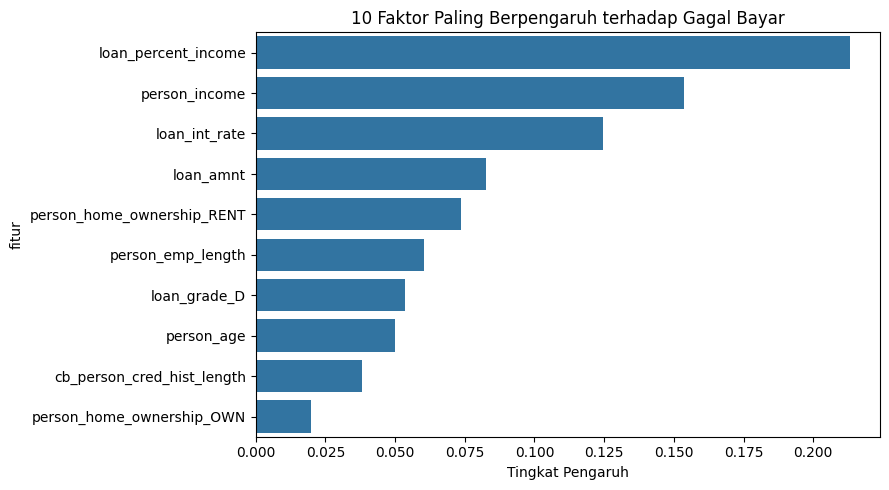

In [43]:
# visualisasi 10 fitur terpenting
plt.figure(figsize=(9, 5))
sns.barplot(x='importance', y='fitur', data=importance.head(10))
plt.title('10 Faktor Paling Berpengaruh terhadap Gagal Bayar')
plt.xlabel('Tingkat Pengaruh')
plt.tight_layout()
plt.show()

### 🔎 Insight Feature Importance

3 faktor teratas penentu gagal bayar:
1. **Rasio pinjaman/income (21%)** — faktor dominan. Konsisten dengan temuan EDA & clustering.
2. **Income (15%)** — penghasilan rendah meningkatkan risiko.
3. **Bunga pinjaman (12%)** — bunga tinggi berkorelasi dengan gagal bayar.

> **Rekomendasi untuk koperasi:** Prioritaskan screening pada rasio pinjaman/income. Terapkan batas maksimal rasio (mis. <25%) sebagai kebijakan mitigasi risiko.